# ComfyUI HTTP Client Test (`image_z_image_turbo`)

This notebook submits a ComfyUI workflow over HTTP and retrieves generated images.

It uses standard ComfyUI endpoints directly:
- `POST /prompt`
- `GET /history/{prompt_id}`
- `GET /view`

Prerequisites:
- ComfyUI server must be running and accessible.
- Enable the `Dev Mode` in the ComfyUI server to allow API access.
- Export the JSON file for the `image_z_image_turbo` workflow from the ComfyUI UI and place it in the same directory as this notebook.
This could be done by going to the ComfyUI UI, clicking on the `image_z_image_turbo` workflow, and then clicking the `Export (API)` button to save the workflow JSON file as shown in the following screenshot.

![Export Workflow JSON](./images/export_workflow_template.png)

First of all, let's get the FQDN of the ComfyUI server.

In [1]:
aca_comfyui_cu126_a100_fqdn = ! terraform output -raw aca_comfyui_cu126_a100_fqdn
aca_comfyui_cu126_a100_fqdn = aca_comfyui_cu126_a100_fqdn.n
print("ComfyUI Endpoint:", aca_comfyui_cu126_a100_fqdn)

ComfyUI Endpoint: comfyui-cu126-a100.gentlebeach-178a8d2a.swedencentral.azurecontainerapps.io


In [4]:
import copy
import json
import time
import uuid
from pathlib import Path
from urllib import parse, request
from IPython.display import Image, display

# -------- Configuration --------
COMFY_BASE_URL = f"http://{aca_comfyui_cu126_a100_fqdn}"
WORKFLOW_PATH = Path("image_z_image_turbo.json")

# Optional run-time overrides
PROMPT_OVERRIDE = "BMW X5 M sport package, in very dark red color, parked on the streets of Tunisia, during the night with street lights illuminating the scene"
SEED_OVERRIDE = None  # e.g. 123456789
STEPS_OVERRIDE = 8  # e.g. 8
WIDTH_OVERRIDE = 1920  # e.g. 1024
HEIGHT_OVERRIDE = 1080  # e.g. 1024
FILENAME_PREFIX_OVERRIDE = "z-image-turbo-api"
TIMEOUT_SECONDS = 180
POLL_SECONDS = 1.0


class ComfyUIClient:
    def __init__(self, base_url: str, client_id: str | None = None, timeout: int = 120):
        self.base_url = base_url.rstrip("/")
        self.client_id = client_id or str(uuid.uuid4())
        self.timeout = timeout

    def _request_json(self, method: str, path: str, *, query: dict | None = None, body: dict | None = None):
        url = f"{self.base_url}{path}"
        headers = {"Content-Type": "application/json"}

        if query:
            url = f"{url}?{parse.urlencode(query)}"

        data = None
        if body is not None:
            data = json.dumps(body).encode("utf-8")

        req = request.Request(url=url, data=data, headers=headers, method=method)
        with request.urlopen(req, timeout=self.timeout) as resp:
            payload = resp.read()
            if not payload:
                return {}
            return json.loads(payload.decode("utf-8"))

    def _request_bytes(self, method: str, path: str, *, query: dict | None = None) -> bytes:
        url = f"{self.base_url}{path}"
        if query:
            url = f"{url}?{parse.urlencode(query)}"

        req = request.Request(url=url, method=method)
        with request.urlopen(req, timeout=self.timeout) as resp:
            return resp.read()

    def queue_prompt(self, workflow: dict) -> str:
        response = self._request_json(
            "POST",
            "/prompt",
            body={"prompt": workflow, "client_id": self.client_id},
        )
        prompt_id = response.get("prompt_id")
        if not prompt_id:
            raise RuntimeError(f"ComfyUI did not return prompt_id. Response: {response}")
        return prompt_id

    def get_history(self, prompt_id: str) -> dict:
        return self._request_json("GET", f"/history/{prompt_id}")

    def get_image_bytes(self, filename: str, subfolder: str = "", folder_type: str = "output") -> bytes:
        return self._request_bytes(
            "GET",
            "/view",
            query={"filename": filename, "subfolder": subfolder, "type": folder_type},
        )


def find_node_ids(workflow: dict):
    prompt_node_id = None
    sampler_node_id = None
    save_node_id = None
    latent_node_id = None

    for node_id, node in workflow.items():
        class_type = node.get("class_type")
        title = (node.get("_meta") or {}).get("title", "")

        if class_type == "CLIPTextEncode" and "Prompt" in title:
            prompt_node_id = node_id
        if class_type == "KSampler":
            sampler_node_id = node_id
        if class_type == "SaveImage":
            save_node_id = node_id
        if class_type == "EmptySD3LatentImage":
            latent_node_id = node_id

    return prompt_node_id, sampler_node_id, save_node_id, latent_node_id


def collect_output_images(history_payload: dict, prompt_id: str):
    prompt_history = history_payload.get(prompt_id)
    if not prompt_history:
        return []

    outputs = prompt_history.get("outputs", {})
    images = []
    for _, output in outputs.items():
        for img in output.get("images", []):
            images.append(
                {
                    "filename": img.get("filename"),
                    "subfolder": img.get("subfolder", ""),
                    "type": img.get("type", "output"),
                }
            )
    return [img for img in images if img.get("filename")]


def wait_for_images(client: ComfyUIClient, prompt_id: str, timeout_seconds: int = 180, poll_seconds: float = 1.0):
    deadline = time.time() + timeout_seconds
    while time.time() < deadline:
        history_payload = client.get_history(prompt_id)
        images = collect_output_images(history_payload, prompt_id)
        if images:
            return images
        time.sleep(poll_seconds)
    raise TimeoutError(f"Timed out waiting for images for prompt_id={prompt_id}")


print("Client helpers loaded.")

Client helpers loaded.


Queued prompt_id: 69c8eb44-1053-49ae-b04d-ae9b9fcc00e1
Generated image count: 1


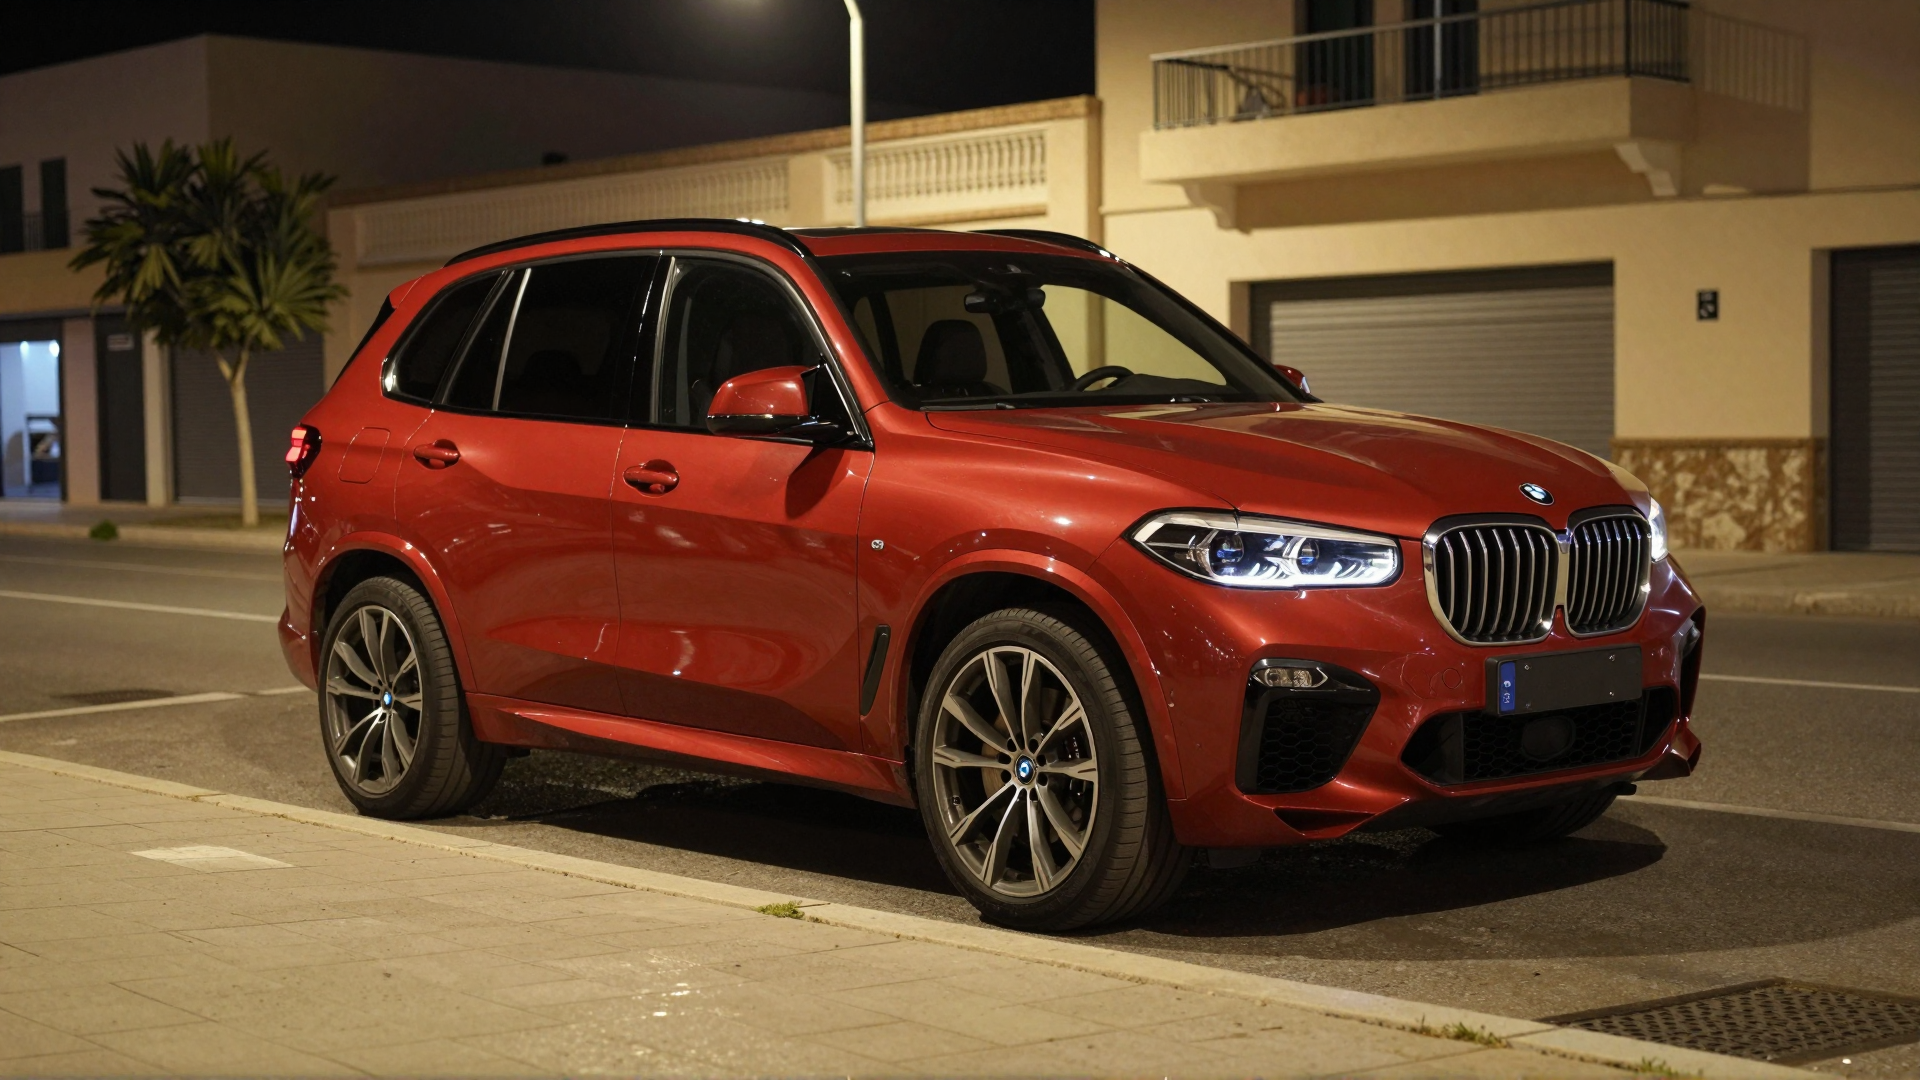

Saved first image to: C:\Users\azureuser\Desktop\ai-course\555_comfyui_on_aca\generated\z-image-turbo-api_00014_.png


[{'filename': 'z-image-turbo-api_00014_.png',
  'subfolder': '',
  'type': 'output'}]

In [5]:
# -------- Load workflow, apply overrides, submit, and display --------
if not WORKFLOW_PATH.exists():
    raise FileNotFoundError(f"Workflow JSON not found: {WORKFLOW_PATH}")

workflow_original = json.loads(WORKFLOW_PATH.read_text(encoding="utf-8"))
workflow = copy.deepcopy(workflow_original)

prompt_node_id, sampler_node_id, save_node_id, latent_node_id = find_node_ids(workflow)

if prompt_node_id and PROMPT_OVERRIDE:
    workflow[prompt_node_id]["inputs"]["text"] = PROMPT_OVERRIDE

if sampler_node_id and SEED_OVERRIDE is not None:
    workflow[sampler_node_id]["inputs"]["seed"] = int(SEED_OVERRIDE)

if sampler_node_id and STEPS_OVERRIDE is not None:
    workflow[sampler_node_id]["inputs"]["steps"] = int(STEPS_OVERRIDE)

if latent_node_id and WIDTH_OVERRIDE is not None:
    workflow[latent_node_id]["inputs"]["width"] = int(WIDTH_OVERRIDE)

if latent_node_id and HEIGHT_OVERRIDE is not None:
    workflow[latent_node_id]["inputs"]["height"] = int(HEIGHT_OVERRIDE)

if save_node_id and FILENAME_PREFIX_OVERRIDE:
    workflow[save_node_id]["inputs"]["filename_prefix"] = FILENAME_PREFIX_OVERRIDE

client = ComfyUIClient(COMFY_BASE_URL)
prompt_id = client.queue_prompt(workflow)
print(f"Queued prompt_id: {prompt_id}")

images = wait_for_images(
    client,
    prompt_id,
    timeout_seconds=TIMEOUT_SECONDS,
    poll_seconds=POLL_SECONDS,
)
print(f"Generated image count: {len(images)}")

# Display first image inline
first = images[0]
img_bytes = client.get_image_bytes(
    filename=first["filename"],
    subfolder=first.get("subfolder", ""),
    folder_type=first.get("type", "output"),
)
display(Image(data=img_bytes))

# Save image locally for convenience
output_dir = Path("generated")
output_dir.mkdir(parents=True, exist_ok=True)
local_path = output_dir / first["filename"]
local_path.write_bytes(img_bytes)
print(f"Saved first image to: {local_path.resolve()}")

images